# Validation & Analysis
Post-training validation of scatterer configurations and transmission matrix analysis.

In [11]:
from inverse_design.envs import BilliardTwoEnv
from inverse_design.enums import MatrixType
from inverse_design.utils import load_best_pos
import numpy as np
import meep as mp

## Prepare Env

In [12]:
env = BilliardTwoEnv()

## Rank 1 TM with zero transmission engenchannel

Load scatter position with rank1 TM.

In [13]:
pos_rank1 = load_best_pos('best_pos_BilliardTwo_Env12_Rank1_PPO_2.npy')

Transmission matrix calculation

In [14]:
normalized_tm = env._calculate_normalized_subSM(pos_rank1, matrix_type=MatrixType.TM)
print(normalized_tm.T)
_, s, _ = np.linalg.svd(normalized_tm)
print(f'Singular values: {s}')

[[ 0.0873252 +0.04351894j -0.02338194-0.09640263j]
 [-0.13438435-0.16349086j -0.04016377+0.21158271j]]
Singular values: [3.32458192e-01 3.25381630e-04]


Steady-state field visualization with zero transmission eigenchannel

a. Excitation from top input waveguide only

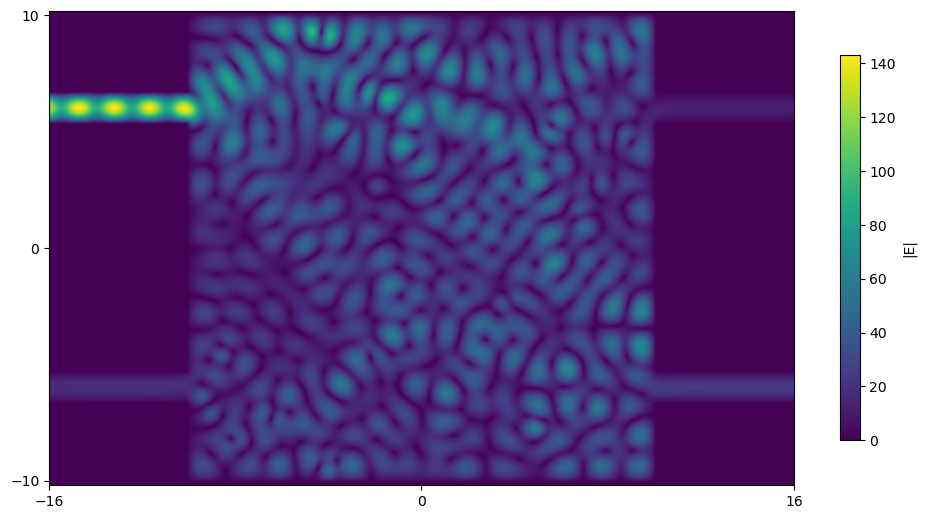

In [15]:
env.plot_steady_state_with_given_inputs(np.array([1, 0]), scatter_pos=pos_rank1, field_component=mp.Ez)

b. Excitation from bottom input waveguide only

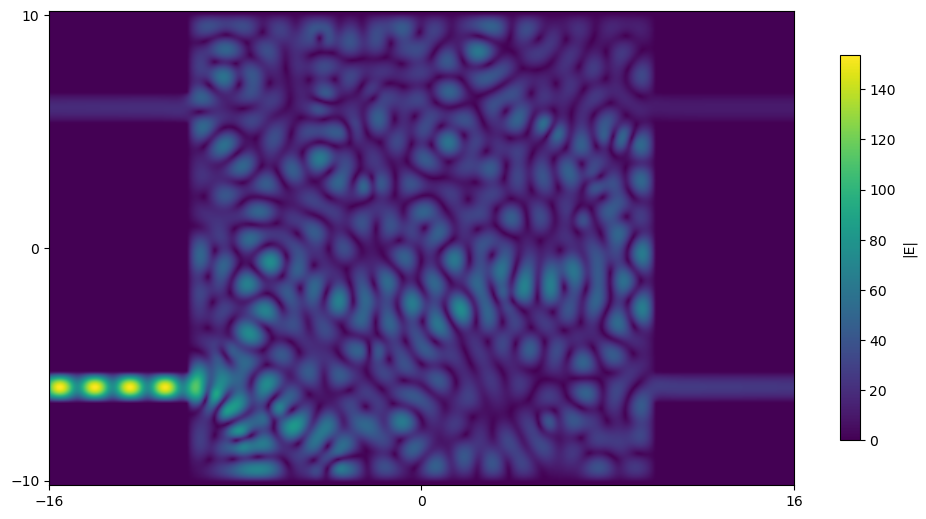

In [16]:
env.plot_steady_state_with_given_inputs(np.array([0, 1]), scatter_pos=pos_rank1, field_component=mp.Ez)

c. Zero transmission eigenchannel

Singular values: [3.32458192e-01 3.25381630e-04]
Lowest Singular values: 0.00032538162983978777


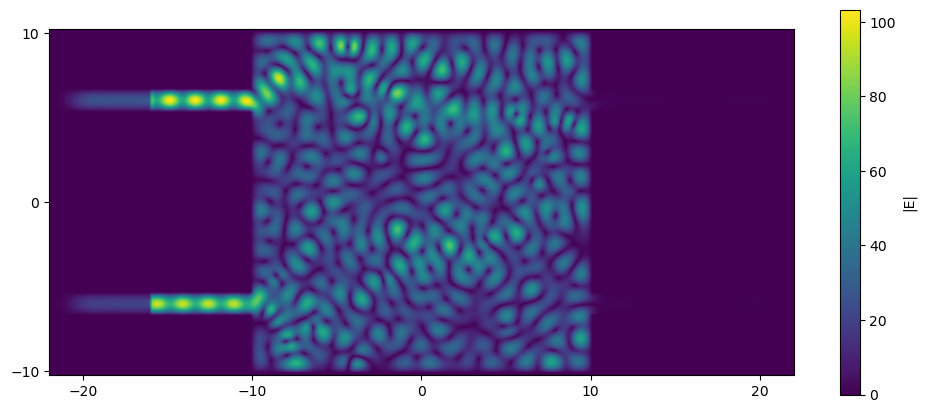

In [17]:
env.plot_lowest_transmission_eigenchannel_steady_state(pos_rank1, field_component=mp.Ez, matrix_type=MatrixType.TM)

## TM with Degenerate eigenvalue

In [18]:
pos_deg_eigenvalue = load_best_pos('best_pos_BilliardTwo_Env12_DegenerateEigVal_PPO_8.npy')
normalized_tm = env._calculate_normalized_subSM(pos_deg_eigenvalue, matrix_type=MatrixType.TM)
eigenvalues, eigenvectors = np.linalg.eig(normalized_tm)
print(eigenvalues)

[0.1591445 +0.27264259j 0.15405264+0.29056119j]


Exceptional point (EP) sweep

In [ ]:
env.find_EP_sweep(
    scatter_pos=pos_deg_eigenvalue,
    scatter_idx=4,
    position_range=(-0.0028, -0.0021),
    position_points=11,
    direction='x',
    freq_range=(0.50004, 0.50008),
    freq_points=12,
    save_path='23'
)

## TM with Degenerate transmission eigenvalues

In [19]:
pos_deg_SingularVal = load_best_pos('best_pos_BilliardTwo_Env12_DegenerateSingularVal_PPO.npy')
normalized_tm = env._calculate_normalized_subSM(pos_deg_SingularVal, matrix_type=MatrixType.TM)
_, s, _ = np.linalg.svd(normalized_tm)
print(f'Singular values: {s}')

Singular values: [0.18604798 0.17865199]
